In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../1.data/processed/nav_history_cleaned.csv")
performance = pd.read_csv("../1.data/processed/scheme_performance_cleaned.csv")

nav['date'] = pd.to_datetime(nav['date'])

print("NAV Shape:", nav.shape)
print("Performance Shape:", performance.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 19)


In [2]:
# Sort by fund and date
nav = nav.sort_values(['amfi_code', 'date'])

# Calculate daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print(nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


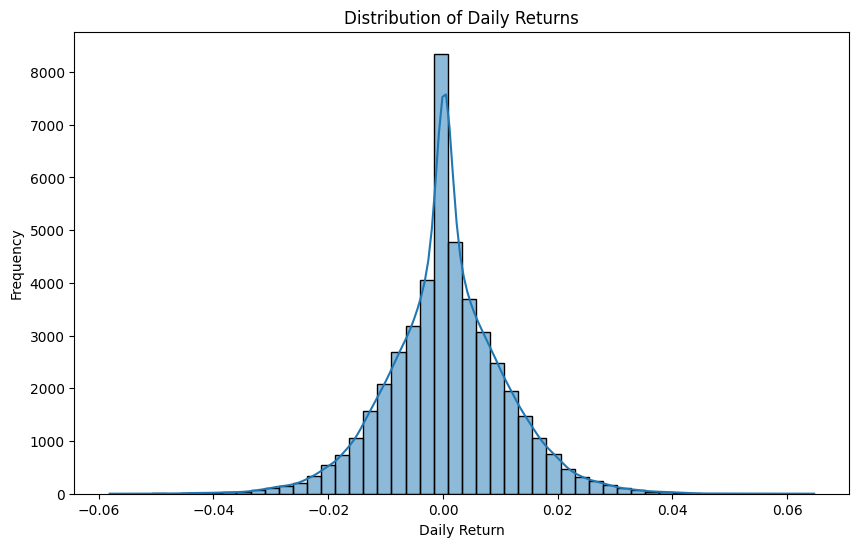

In [3]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

### Daily Return Analysis

Daily returns are centered near zero with a relatively symmetric distribution, indicating normal market fluctuations and reasonable data quality.

In [4]:
print(performance.head())
print(performance.columns)

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [5]:
cagr_table = performance[[
    'scheme_name',
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct'
]]

cagr_table = cagr_table.sort_values(
    by='return_5yr_pct',
    ascending=False
)

cagr_table.head(10)

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80
27,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
39,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61
38,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00
26,Axis Midcap Fund - Regular - Growth,14.88,15.18,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69


In [6]:
cagr_table.to_csv(
    "../5.reports/cagr_comparison.csv",
    index=False
)

print("CAGR table saved successfully!")

CAGR table saved successfully!


### CAGR Analysis

Small-cap and mid-cap funds generally delivered higher long-term returns, while debt-oriented funds exhibited relatively stable but lower growth rates.

In [7]:
sharpe_rank = performance[[
    'scheme_name',
    'sharpe_ratio'
]].sort_values(
    by='sharpe_ratio',
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [8]:
sharpe_rank.to_csv(
    "../5.reports/sharpe_ranking.csv",
    index=False
)

print("Sharpe ranking saved!")

Sharpe ranking saved!


### Sharpe Ratio Analysis

Funds with higher Sharpe ratios generated superior risk-adjusted returns, indicating better compensation for the level of volatility undertaken.

In [9]:
alpha_beta = performance[[
    'scheme_name',
    'alpha',
    'beta'
]].sort_values(
    by='alpha',
    ascending=False
)

alpha_beta.head(10)

,scheme_name,alpha,beta
9,HDFC Short Term Debt Fund - Regular - Growth,1.98,0.44
21,Kotak Emerging Equity Fund - Regular - Growth,1.91,1.00
14,ICICI Pru Liquid Fund - Regular - Growth,1.85,0.26
22,Kotak Flexicap Fund - Regular - Growth,1.85,0.95
29,ABSL Small Cap Fund - Regular - Growth,1.84,0.97
37,DSP Top 100 Equity Fund - Regular - Growth,1.82,0.91
18,Nippon India ETF Nifty 50 BeES,1.80,1.04
33,UTI Flexi Cap Fund - Regular - Growth,1.79,1.00
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70,0.99


In [10]:
alpha_beta.to_csv(
    "../5.reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [11]:
sortino_rank = performance[[
    'scheme_name',
    'sortino_ratio'
]].sort_values(
    by='sortino_ratio',
    ascending=False
)

sortino_rank.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [12]:
drawdown_rank = performance[[
    'scheme_name',
    'max_drawdown_pct'
]].sort_values(
    by='max_drawdown_pct',
    ascending=False
)

drawdown_rank.head(10)

,scheme_name,max_drawdown_pct
19,Nippon India Gilt Securities Fund - Regular - ...,-2.23
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-2.30
14,ICICI Pru Liquid Fund - Regular - Growth,-2.62
30,ABSL Liquid Fund - Regular - Growth,-3.66
23,Kotak Liquid Fund - Regular - Growth,-3.81
9,HDFC Short Term Debt Fund - Regular - Growth,-6.01
33,UTI Flexi Cap Fund - Regular - Growth,-12.14
2,SBI Small Cap Fund - Regular Plan - Growth,-13.35
32,UTI Mid Cap Fund - Regular - Growth,-13.43
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-13.67


In [13]:
scorecard = performance.copy()

# Rank calculations
scorecard['return_rank'] = scorecard['return_3yr_pct'].rank(pct=True)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(pct=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(pct=True)

# Lower expense ratio is better
scorecard['expense_rank'] = (
    1 - scorecard['expense_ratio_pct'].rank(pct=True)
)

# Lower drawdown is better
scorecard['drawdown_rank'] = (
    1 - scorecard['max_drawdown_pct'].rank(pct=True)
)

# Composite score
scorecard['fund_score'] = (
    scorecard['return_rank'] * 30 +
    scorecard['sharpe_rank'] * 25 +
    scorecard['alpha_rank'] * 20 +
    scorecard['expense_rank'] * 15 +
    scorecard['drawdown_rank'] * 10
)

scorecard = scorecard.sort_values(
    by='fund_score',
    ascending=False
)

scorecard[[
    'scheme_name',
    'fund_score'
]].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,72.1250
22,Kotak Flexicap Fund - Regular - Growth,70.8750
21,Kotak Emerging Equity Fund - Regular - Growth,69.8750
29,ABSL Small Cap Fund - Regular - Growth,67.6250
2,SBI Small Cap Fund - Regular Plan - Growth,63.7500
34,Mirae Asset Large Cap Fund - Regular - Growth,63.3125
9,HDFC Short Term Debt Fund - Regular - Growth,62.3750
14,ICICI Pru Liquid Fund - Regular - Growth,61.1250
12,ICICI Pru Midcap Fund - Regular - Growth,60.3750
11,ICICI Pru Bluechip Fund - Direct - Growth,59.0000


In [14]:
scorecard.to_csv(
    "../5.reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


### Fund Scorecard Analysis

The composite scorecard highlights funds that balance return generation, risk-adjusted performance, alpha creation, cost efficiency, and drawdown control, providing a holistic performance assessment.